# TP3 — Detección del logotipo de Coca-Cola

**Integrantes:**
- Julián Barceló
- Jonatan Mild
- Víctor Hugo Astorga
- Roberto Manuel Briend
- Valentín Torres

**Materia:** Visión por Computadora I

**Material:** `template/pattern.png` y las 7 imágenes de `images/`

---

### Objetivo

Localizar el logotipo de la gaseosa dentro de las imágenes provistas usando **un único template**,
sin entrenar ningún modelo. El trabajo se resuelve con **template matching multi-escala**
(`cv.matchTemplate` con `TM_CCOEFF_NORMED`), que es el algoritmo visto en la Clase 4, y se valida
de forma cuantitativa contra un ground truth anotado a mano. Como cierre se contrasta el resultado
con un enfoque por **características locales** (SIFT + FLANN + homografía con RANSAC, Clase 5).

## Consigna

1. **(4 pts)** Obtener **una** detección del logo en cada imagen, **sin falsos positivos**.
2. **(4 pts)** Plantear y **validar** un algoritmo para **múltiples detecciones** en `coca_multi.png`
   con el mismo template del ítem 1.
3. **(2 pts)** **Generalizar** el algoritmo del ítem 2 para todas las imágenes.

En todos los casos hay que visualizar los resultados con **bounding boxes** mostrando el **nivel de
confianza** de la detección.

### Resumen del enfoque

El detector es uno solo y se usa en los tres puntos; lo único que cambia es la regla con la que se
seleccionan las detecciones sobre la lista de candidatos:

| Punto | Regla de selección |
|---|---|
| 1 | El candidato de mayor confianza de la imagen (top-1). |
| 2 | Todos los candidatos que superan un piso absoluto **y** un umbral relativo al mejor de la imagen. |
| 3 | La misma regla del punto 2, aplicada tal cual a las 7 imágenes. |

Los cuatro ingredientes que hacen que eso funcione sobre este dataset son:

1. **Recorte automático del template** (saca el margen blanco que no aporta información).
2. **Búsqueda multi-escala y multi-relación de aspecto** (el logo aparece desde 87 px hasta 1200 px
   de ancho, y deformado sobre superficies cilíndricas).
3. **Doble polaridad** del template: el logo aparece tanto en rojo sobre blanco como en blanco
   sobre rojo, y `TM_CCOEFF_NORMED` **no** es invariante a la inversión de contraste.
4. **Normalización del pico por z-score** dentro de cada mapa de correlación, para poder comparar
   respuestas obtenidas con templates de distinto tamaño.

## Configuración

In [1]:
%matplotlib inline

import time
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

TEMPLATE_PATH = Path('template') / 'pattern.png'
IMAGES_DIR = Path('images')
MULTI_IMAGE = 'coca_multi.png'

# --- Búsqueda multi-escala / multi-aspecto -----------------------------------
FACTOR_ESCALA = 1.08                                   # paso geométrico entre escalas
ESCALAS = FACTOR_ESCALA ** np.arange(-26, 17)          # 0.14x .. 3.4x del template recortado
ASPECTOS = (0.85, 1.00, 1.18, 1.35)                    # alto/ancho relativo al template
ANCHO_MIN = 60                                         # px: ancho mínimo del template escalado

# --- Umbrales de confianza (z = pico normalizado del mapa de correlación) ----
Z_CANDIDATO = 3.0        # piso para generar candidatos
Z_MIN = 4.0              # piso absoluto para aceptar una detección
Z_REL = 0.70             # fracción del mejor z de la imagen

# --- Supresión de no máximos --------------------------------------------------
NMS_IOU = 0.30           # solapamiento máximo admitido entre dos detecciones
NMS_DIST = 0.50          # distancia mínima entre centros, en fracción del ancho medio

# --- Validación ---------------------------------------------------------------
IOU_ACIERTO = 0.30       # IoU mínimo contra el ground truth para contar un acierto
LOWE_RATIO = 0.75        # ratio de Lowe para el matching de descriptores SIFT

imagenes = sorted(p.name for p in IMAGES_DIR.iterdir() if not p.name.startswith('.'))
print(f'{len(imagenes)} imágenes:', imagenes)
print(f'{len(ESCALAS)} escalas entre {ESCALAS.min():.2f}x y {ESCALAS.max():.2f}x')

7 imágenes: ['COCA-COLA-LOGO.jpg', 'coca_logo_1.png', 'coca_logo_2.png', 'coca_multi.png', 'coca_retro_1.png', 'coca_retro_2.png', 'logo_1.png']
43 escalas entre 0.14x y 3.43x


## El material

El template es el logotipo "limpio": el lettering rojo sobre fondo blanco. Las imágenes, en cambio,
lo muestran en situaciones muy distintas —etiquetas curvas, un aviso de diario en blanco y negro,
una góndola con muchas botellas— y con tamaños que van de decenas a más de mil píxeles de ancho.

Template: 400x175 px
  COCA-COLA-LOGO.jpg      1389x1389 
  coca_logo_1.png          207x500  
  coca_logo_2.png          233x363  
  coca_multi.png           799x598  
  coca_retro_1.png         715x493  
  coca_retro_2.png         715x429  
  logo_1.png               687x450  


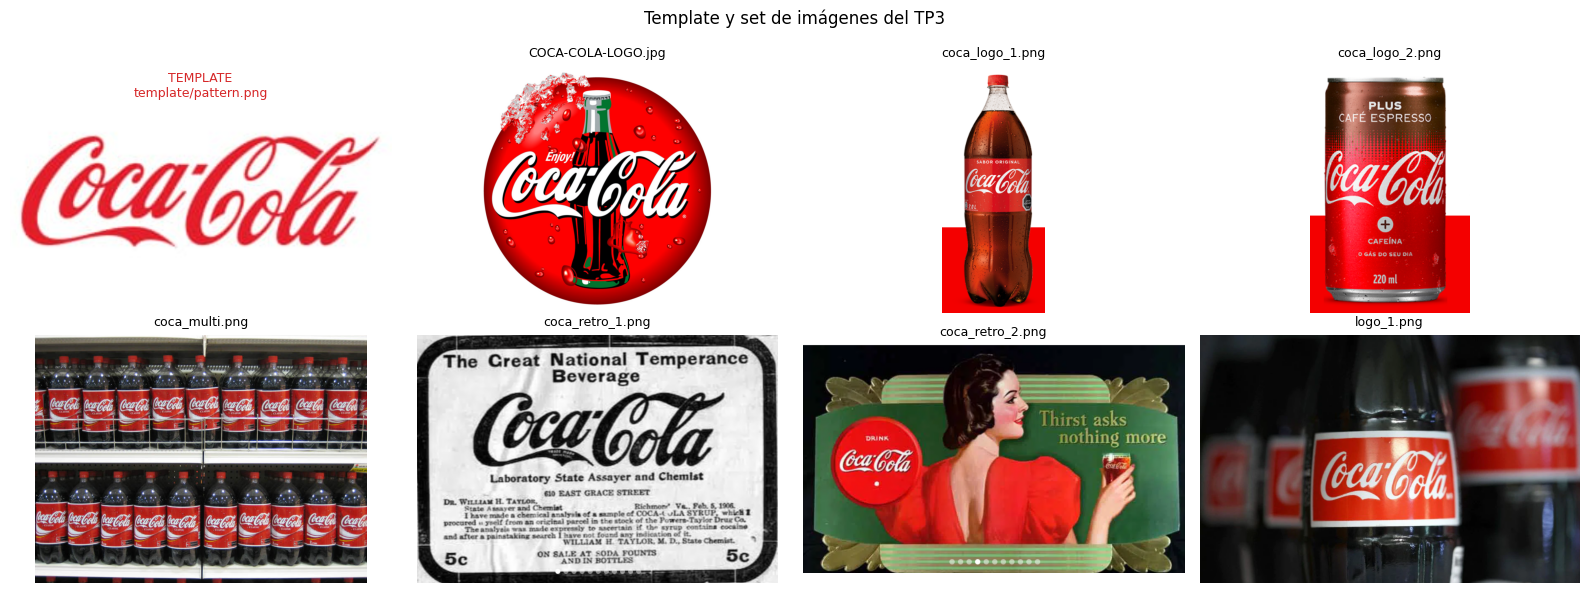

In [2]:
def cargar(nombre: str) -> np.ndarray:
    """Carga una imagen de `images/` en BGR."""
    img = cv.imread(str(IMAGES_DIR / nombre))
    if img is None:
        raise FileNotFoundError(nombre)
    return img


template_bgr = cv.imread(str(TEMPLATE_PATH))
print(f'Template: {template_bgr.shape[1]}x{template_bgr.shape[0]} px')
for nombre in imagenes:
    alto, ancho = cargar(nombre).shape[:2]
    print(f'  {nombre:22s} {ancho:5d}x{alto:<5d}')

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.ravel()
axes[0].imshow(cv.cvtColor(template_bgr, cv.COLOR_BGR2RGB))
axes[0].set_title('TEMPLATE\ntemplate/pattern.png', fontsize=9, color='tab:red')
axes[0].axis('off')
for ax, nombre in zip(axes[1:], imagenes):
    ax.imshow(cv.cvtColor(cargar(nombre), cv.COLOR_BGR2RGB))
    ax.set_title(nombre, fontsize=9)
    ax.axis('off')
plt.suptitle('Template y set de imágenes del TP3')
plt.tight_layout()
plt.show()

## Preprocesamiento del template

Dos decisiones antes de empezar a correlacionar:

**1. Recorte automático.** El template viene con un margen blanco de ~30 px que no pertenece al
logo. Ese margen es superficie constante que se promedia dentro de la ventana de correlación y
degrada el contraste de la métrica, además de forzar a que la caja detectada sea más grande que el
logo real. Se lo elimina buscando el bounding box de los píxeles que se apartan del blanco.

**2. Doble polaridad.** `TM_CCOEFF_NORMED` mide la correlación entre las variaciones de intensidad
del template y de la imagen: si se invierte el contraste, la correlación cambia de signo y el match
correcto deja de ser un máximo. En el template el lettering es **oscuro sobre claro** (rojo sobre
blanco), pero en la mayoría de las imágenes es **claro sobre oscuro** (blanco sobre rojo). Por eso
se busca con las dos versiones del template —directa e invertida— y se conserva la mejor.

Template original: 400x175 px
Template recortado: 376x119 px


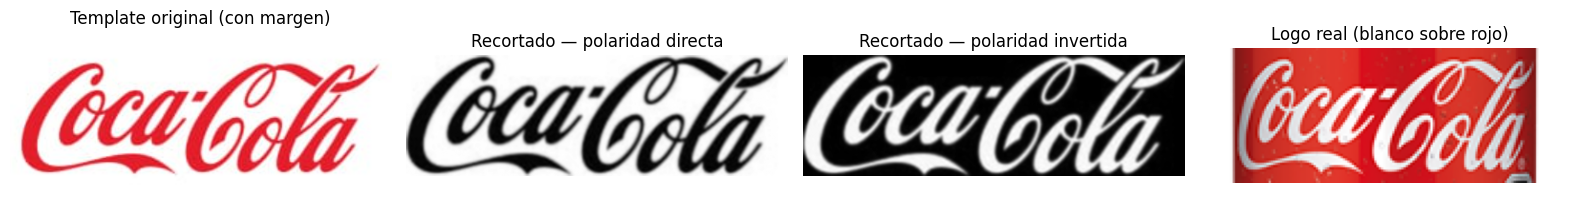

In [3]:
def recortar_template(bgr: np.ndarray, umbral_blanco: int = 240) -> np.ndarray:
    """Recorta el margen blanco del template quedándose con el bounding box de la tinta."""
    gris = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    ys, xs = np.where(gris < umbral_blanco)
    return bgr[ys.min():ys.max() + 1, xs.min():xs.max() + 1]


def preprocesar(bgr: np.ndarray) -> np.ndarray:
    """Escala de grises + blur gaussiano (atenúa ruido y textura fina)."""
    return cv.GaussianBlur(cv.cvtColor(bgr, cv.COLOR_BGR2GRAY), (5, 5), 1)


def variantes_template(bgr: np.ndarray) -> tuple:
    """Template preprocesado en sus dos polaridades."""
    base = preprocesar(recortar_template(bgr))
    return (('directa', base), ('invertida', 255 - base))


VARIANTES = variantes_template(template_bgr)
recorte = recortar_template(template_bgr)
print(f'Template original: {template_bgr.shape[1]}x{template_bgr.shape[0]} px')
print(f'Template recortado: {recorte.shape[1]}x{recorte.shape[0]} px')

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
axes[0].imshow(cv.cvtColor(template_bgr, cv.COLOR_BGR2RGB))
axes[0].set_title('Template original (con margen)')
axes[1].imshow(VARIANTES[0][1], cmap='gray')
axes[1].set_title('Recortado — polaridad directa')
axes[2].imshow(VARIANTES[1][1], cmap='gray')
axes[2].set_title('Recortado — polaridad invertida')
axes[3].imshow(cv.cvtColor(cargar('coca_logo_1.png')[205:265, 30:200], cv.COLOR_BGR2RGB))
axes[3].set_title('Logo real (blanco sobre rojo)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## El detector

El barrido recorre, para cada polaridad del template, una **pirámide de escalas** en progresión
geométrica y cuatro **relaciones de aspecto** (el logo impreso sobre una lata o una botella aparece
estirado verticalmente respecto del template plano). Para cada combinación se calcula el mapa de
correlación completo con `cv.matchTemplate`.

### El problema de comparar picos entre escalas

`TM_CCOEFF_NORMED` devuelve valores acotados en $[-1, 1]$, pero **esos valores no son comparables
entre templates de distinto tamaño**: cuanto más chico es el template, menos píxeles entran en la
correlación y más fácil es que una zona cualquiera de la imagen se le parezca "de casualidad". El
resultado práctico es que el máximo global sobre toda la pirámide tiende a caer en las escalas más
chicas, sobre parches que no tienen nada que ver con el logo.

La solución que usamos es normalizar cada pico **respecto de su propio mapa de correlación**:

$$z = \frac{r_{max} - \mu_r}{\sigma_r}$$

donde $\mu_r$ y $\sigma_r$ son la media y el desvío del mapa de correlación de esa escala. Es la
idea del *peak-to-sidelobe ratio*: no interesa cuán alta es la respuesta en términos absolutos, sino
**cuánto se despega del resto de las respuestas de esa misma configuración**. Así definido, $z$ sí
es comparable entre escalas, aspectos y polaridades, y es el score que usamos para rankear.

De cada mapa se conservan únicamente los **máximos locales** (comparando contra una dilatación 5x5),
que es lo que evita arrastrar miles de candidatos redundantes alrededor de cada pico.

In [4]:
def barrer(img_bgr: np.ndarray, variantes=VARIANTES, z_min: float = Z_CANDIDATO,
           escalas=ESCALAS, aspectos=ASPECTOS, ancho_min: int = ANCHO_MIN) -> list:
    """Template matching multi-escala / multi-aspecto / doble polaridad.

    Devuelve la lista de candidatos (máximos locales de cada mapa de correlación con
    z >= `z_min`), cada uno con su caja, su NCC y su z.
    """
    img = preprocesar(img_bgr)
    alto_img, ancho_img = img.shape
    candidatos = []
    for polaridad, base in variantes:
        for escala in escalas:
            ancho = int(round(base.shape[1] * escala))
            if ancho < ancho_min or ancho > ancho_img:
                continue
            for aspecto in aspectos:
                alto = int(round(base.shape[0] * escala * aspecto))
                if alto < 15 or alto > alto_img:
                    continue
                tmpl = cv.resize(base, (ancho, alto), interpolation=cv.INTER_AREA)
                r = cv.matchTemplate(img, tmpl, cv.TM_CCOEFF_NORMED)
                z = (r - r.mean()) / (r.std() + 1e-9)
                picos = (z >= z_min) & (z == cv.dilate(z, np.ones((5, 5), np.float32)))
                for y, x in zip(*np.where(picos)):
                    candidatos.append({
                        'caja': (int(x), int(y), ancho, alto),
                        'ncc': float(r[y, x]), 'z': float(z[y, x]),
                        'escala': float(escala), 'aspecto': aspecto, 'polaridad': polaridad,
                    })
    return sorted(candidatos, key=lambda c: -c['z'])

### Supresión de no máximos

Un mismo logo genera picos en varias escalas, aspectos y polaridades vecinas. El NMS clásico por
**IoU** no alcanza en este caso: una caja chica apoyada sobre una parte del logo (por ejemplo la
palabra *CLASSIC* debajo del lettering) tiene IoU bajo contra la caja buena y sobrevive como
detección duplicada.

Por eso al criterio de IoU se le suma uno de **distancia entre centros**: dos instancias reales del
logo no pueden tener sus centros más cerca que media anchura de caja, porque son objetos físicos que
no se superponen. Se recorren los candidatos de mayor a menor $z$ y se descarta todo el que caiga
demasiado cerca de uno ya aceptado.

In [5]:
def iou(caja_a: tuple, caja_b: tuple) -> float:
    """Intersection over Union entre dos cajas (x, y, w, h)."""
    ax, ay, aw, ah = caja_a
    bx, by, bw, bh = caja_b
    ancho = max(0, min(ax + aw, bx + bw) - max(ax, bx))
    alto = max(0, min(ay + ah, by + bh) - max(ay, by))
    inter = ancho * alto
    return inter / (aw * ah + bw * bh - inter) if inter else 0.0


def nms(candidatos: list, iou_max: float = NMS_IOU, dist_min: float = NMS_DIST) -> list:
    """Supresión de no máximos por IoU y por distancia entre centros."""
    conservados = []
    for cand in sorted(candidatos, key=lambda c: -c['z']):
        x, y, w, h = cand['caja']
        cx, cy = x + w / 2, y + h / 2
        duplicado = False
        for otro in conservados:
            ox, oy, ow, oh = otro['caja']
            distancia = np.hypot(cx - (ox + ow / 2), cy - (oy + oh / 2))
            if iou(cand['caja'], otro['caja']) > iou_max or distancia < dist_min * (w + ow) / 2:
                duplicado = True
                break
        if not duplicado:
            conservados.append(cand)
    return conservados


def dibujar(img_bgr: np.ndarray, detecciones: list, color=(0, 255, 0)) -> np.ndarray:
    """Dibuja las cajas con su nivel de confianza (NCC)."""
    salida = img_bgr.copy()
    grosor = max(1, int(round(min(salida.shape[:2]) / 300)))
    for det in detecciones:
        x, y, w, h = det['caja']
        cv.rectangle(salida, (x, y), (x + w, y + h), color, grosor)
        cv.putText(salida, f"{det['ncc']:.2f}", (x, max(y - 5, 14)),
                   cv.FONT_HERSHEY_SIMPLEX, 0.5 * grosor, color, grosor, cv.LINE_AA)
    return salida


def mostrar(img_bgr: np.ndarray, titulo: str, ancho: float = 7.0):
    alto = ancho * img_bgr.shape[0] / img_bgr.shape[1]
    plt.figure(figsize=(ancho, alto))
    plt.imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()

### Verificación de la normalización por z-score

`coca_logo_2.png` (la lata de café espresso) es el caso donde se ve el problema en estado puro. Es
una imagen oscura, con degradé y con el lettering deformado sobre una superficie cilíndrica: el logo
verdadero correlaciona apenas 0.23, y el máximo global de NCC termina cayendo sobre el bloque de
texto superior de la lata, con una escala más chica. Rankeando por $z$ el máximo vuelve al logo.

El mismo experimento sirve para justificar `ANCHO_MIN`: si se deja que el barrido use templates
todavía más chicos, el máximo de NCC se corre a un parche de 55x15 px que no tiene nada que ver con
el logo, mientras que el máximo de $z$ no se mueve.

Máximo por NCC crudo : ncc=0.338  z=3.55  caja=(39, 4, 174, 74)  escala=0.46
Máximo por z-score   : ncc=0.234  z=4.72  caja=(4, 125, 219, 82)  escala=0.58



Sin ANCHO_MIN — máximo por NCC : ncc=0.352  z=3.82  caja=(146, 199, 55, 15)  escala=0.15
Sin ANCHO_MIN — máximo por z   : ncc=0.234  z=4.72  caja=(4, 125, 219, 82)  escala=0.58


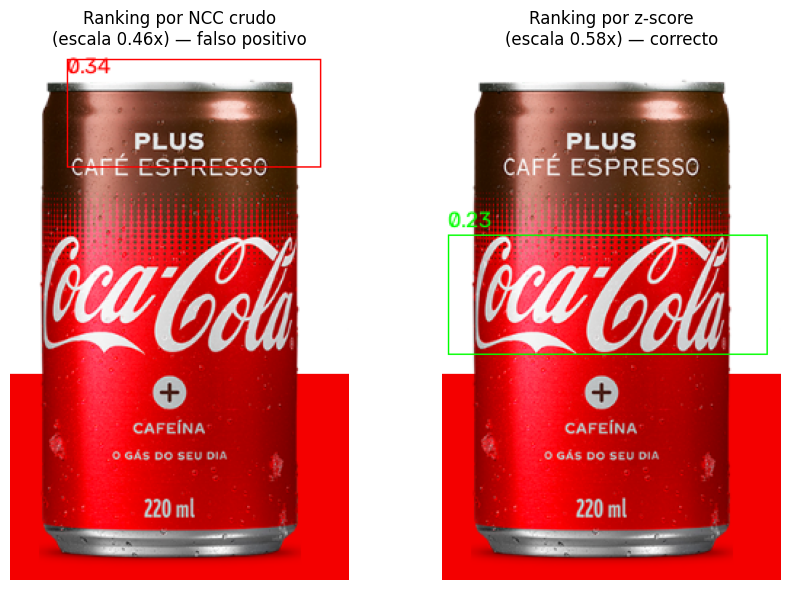

In [6]:
demo = cargar('coca_logo_2.png')
cands_demo = barrer(demo)
mejor_ncc = max(cands_demo, key=lambda c: c['ncc'])
mejor_z = max(cands_demo, key=lambda c: c['z'])

print(f"Máximo por NCC crudo : ncc={mejor_ncc['ncc']:.3f}  z={mejor_ncc['z']:.2f}  "
      f"caja={mejor_ncc['caja']}  escala={mejor_ncc['escala']:.2f}")
print(f"Máximo por z-score   : ncc={mejor_z['ncc']:.3f}  z={mejor_z['z']:.2f}  "
      f"caja={mejor_z['caja']}  escala={mejor_z['escala']:.2f}")

# Sin el ancho mínimo, el NCC se va a templates diminutos; el z-score no se mueve
cands_chicos = barrer(demo, ancho_min=25)
peor = max(cands_chicos, key=lambda c: c['ncc'])
estable = max(cands_chicos, key=lambda c: c['z'])
print(f"\nSin ANCHO_MIN — máximo por NCC : ncc={peor['ncc']:.3f}  z={peor['z']:.2f}  "
      f"caja={peor['caja']}  escala={peor['escala']:.2f}")
print(f"Sin ANCHO_MIN — máximo por z   : ncc={estable['ncc']:.3f}  z={estable['z']:.2f}  "
      f"caja={estable['caja']}  escala={estable['escala']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 6))
axes[0].imshow(cv.cvtColor(dibujar(demo, [mejor_ncc], (0, 0, 255)), cv.COLOR_BGR2RGB))
axes[0].set_title(f"Ranking por NCC crudo\n(escala {mejor_ncc['escala']:.2f}x) — falso positivo")
axes[1].imshow(cv.cvtColor(dibujar(demo, [mejor_z]), cv.COLOR_BGR2RGB))
axes[1].set_title(f"Ranking por z-score\n(escala {mejor_z['escala']:.2f}x) — correcto")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

### Barrido de todas las imágenes

El barrido es la parte cara del algoritmo (son ~340 llamadas a `matchTemplate` por imagen), así que
se corre **una sola vez** y los tres puntos del TP trabajan sobre la misma lista de candidatos.

In [7]:
t0 = time.time()
CANDIDATOS = {}
for nombre in imagenes:
    inicio = time.time()
    CANDIDATOS[nombre] = nms(barrer(cargar(nombre)))
    print(f'{nombre:22s} {len(CANDIDATOS[nombre]):3d} candidatos tras NMS '
          f'({time.time() - inicio:5.1f} s)')
print(f'\nTotal: {time.time() - t0:.1f} s')

COCA-COLA-LOGO.jpg     209 candidatos tras NMS ( 16.9 s)


coca_logo_1.png         13 candidatos tras NMS (  0.3 s)
coca_logo_2.png          9 candidatos tras NMS (  0.2 s)


coca_multi.png          23 candidatos tras NMS (  2.9 s)


coca_retro_1.png        27 candidatos tras NMS (  2.0 s)


coca_retro_2.png        40 candidatos tras NMS (  1.6 s)


logo_1.png              22 candidatos tras NMS (  1.6 s)

Total: 25.6 s


## Punto 1 — Una detección por imagen, sin falsos positivos

La regla es la más simple posible: **el candidato de mayor $z$ de la imagen**. Al devolver una única
caja por imagen, la condición de "sin falsos positivos" se cumple si y solo si ese máximo cae sobre
el logo verdadero, cosa que se verifica visualmente y, en la sección siguiente, midiendo IoU contra
un ground truth anotado a mano.

In [8]:
def detectar_una(nombre: str) -> list:
    """Punto 1: la detección de mayor confianza de la imagen."""
    return CANDIDATOS[nombre][:1]


punto1 = {nombre: detectar_una(nombre) for nombre in imagenes}

print(f"{'imagen':22s}{'NCC':>7}{'z':>7}{'escala':>8}{'aspecto':>9}  {'polaridad':11s}caja")
for nombre, dets in punto1.items():
    d = dets[0]
    print(f"{nombre:22s}{d['ncc']:7.3f}{d['z']:7.2f}{d['escala']:8.2f}{d['aspecto']:9.2f}  "
          f"{d['polaridad']:11s}{d['caja']}")

imagen                    NCC      z  escala  aspecto  polaridad  caja
COCA-COLA-LOGO.jpg      0.705   8.27    3.17     1.00  invertida  (86, 480, 1193, 377)
coca_logo_1.png         0.408   6.61    0.37     1.18  invertida  (42, 209, 138, 52)
coca_logo_2.png         0.234   4.72    0.58     1.18  invertida  (4, 125, 219, 82)
coca_multi.png          0.558   5.37    0.21     1.18  invertida  (280, 152, 81, 30)
coca_retro_1.png        0.689   8.29    1.36     1.00  directa    (109, 105, 512, 162)
coca_retro_2.png        0.651   7.77    0.40     0.85  invertida  (63, 198, 149, 40)
logo_1.png              0.421   6.03    0.74     1.00  invertida  (205, 213, 276, 87)


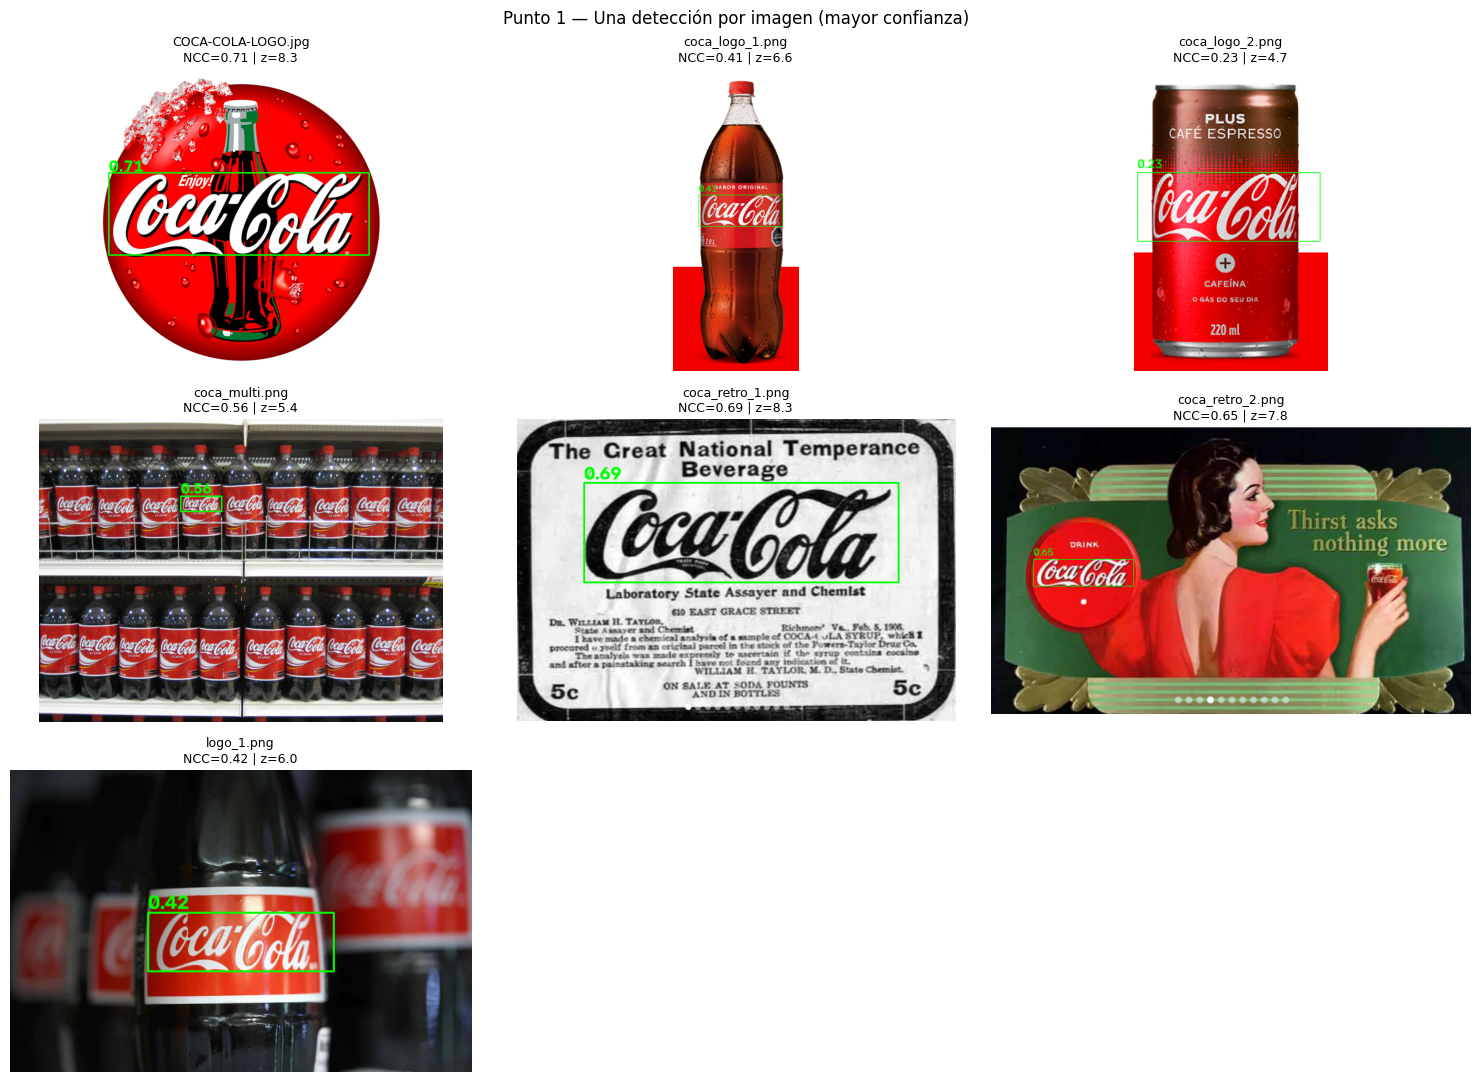

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()
for ax, nombre in zip(axes, imagenes):
    det = punto1[nombre][0]
    ax.imshow(cv.cvtColor(dibujar(cargar(nombre), punto1[nombre]), cv.COLOR_BGR2RGB))
    ax.set_title(f"{nombre}\nNCC={det['ncc']:.2f} | z={det['z']:.1f}", fontsize=9)
    ax.axis('off')
for ax in axes[len(imagenes):]:
    ax.axis('off')
plt.suptitle('Punto 1 — Una detección por imagen (mayor confianza)')
plt.tight_layout()
plt.show()

## Validación: ground truth y protocolo de evaluación

Para no quedarnos en "se ve bien", se anotaron a mano las cajas de todos los logos del dataset.
Las instancias **cortadas por el borde de la imagen** o **fuertemente desenfocadas** se marcan como
`dificiles`: no se cuentan como aciertos ni como omisiones, porque no son detectables con un
template completo, pero tampoco se penaliza si el detector las encuentra. Son 24 logos evaluables
y 5 marcados como difíciles.

**Criterio de acierto:** una detección es correcta (TP) si su IoU contra una caja del ground truth
todavía no asignada es ≥ 0.30; cada caja del ground truth puede asignarse a lo sumo a una detección.
El umbral es laxo a propósito: la anotación es manual y el template incluye el logo completo, así
que exigir 0.5 castigaría diferencias de encuadre que no son errores de detección.

In [10]:
GROUND_TRUTH = {
    'COCA-COLA-LOGO.jpg': {'logos': [(120, 470, 1150, 390)], 'dificiles': []},
    'coca_logo_1.png': {'logos': [(35, 208, 160, 55)], 'dificiles': []},
    'coca_logo_2.png': {'logos': [(12, 128, 208, 68)], 'dificiles': []},
    'coca_retro_1.png': {'logos': [(105, 105, 520, 165)], 'dificiles': []},
    # el segundo logo del afiche está impreso sobre el vaso: 44x14 px
    'coca_retro_2.png': {'logos': [(62, 198, 152, 42)], 'dificiles': [(565, 221, 44, 14)]},
    # la botella del fondo tiene el logo legible pero fuera de foco
    'logo_1.png': {'logos': [(208, 213, 270, 88)], 'dificiles': [(480, 127, 196, 60)]},
    'coca_multi.png': {
        'logos': [(x, 152, 85, 32) for x in (30, 110, 200, 275, 370, 445, 545, 630, 705)] +
                 [(x, 428, 85, 32) for x in (0, 70, 150, 230, 305, 405, 485, 565, 655)],
        'dificiles': [(0, 152, 18, 32), (775, 152, 24, 32), (745, 428, 54, 32)],
    },
}

total_logos = sum(len(g['logos']) for g in GROUND_TRUTH.values())
total_dificiles = sum(len(g['dificiles']) for g in GROUND_TRUTH.values())
print(f'Ground truth: {total_logos} logos evaluables + {total_dificiles} marcados como difíciles')


def evaluar(detecciones: list, gt: dict, iou_min: float = IOU_ACIERTO) -> dict:
    """Compara detecciones contra el ground truth de una imagen."""
    pendientes = list(gt['logos'])
    tp = fp = dificiles = 0
    for det in sorted(detecciones, key=lambda d: -d['z']):
        solapes = [iou(det['caja'], g) for g in pendientes]
        if solapes and max(solapes) >= iou_min:
            pendientes.pop(int(np.argmax(solapes)))
            tp += 1
        elif any(iou(det['caja'], g) >= iou_min for g in gt['dificiles']):
            dificiles += 1
        else:
            fp += 1
    return {'TP': tp, 'FP': fp, 'FN': len(pendientes), 'dificiles': dificiles}


def resumir(resultados: dict) -> dict:
    """Agrega métricas de varias imágenes."""
    tp = sum(r['TP'] for r in resultados.values())
    fp = sum(r['FP'] for r in resultados.values())
    fn = sum(r['FN'] for r in resultados.values())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {'TP': tp, 'FP': fp, 'FN': fn, 'precision': precision, 'recall': recall, 'f1': f1}

Ground truth: 24 logos evaluables + 5 marcados como difíciles


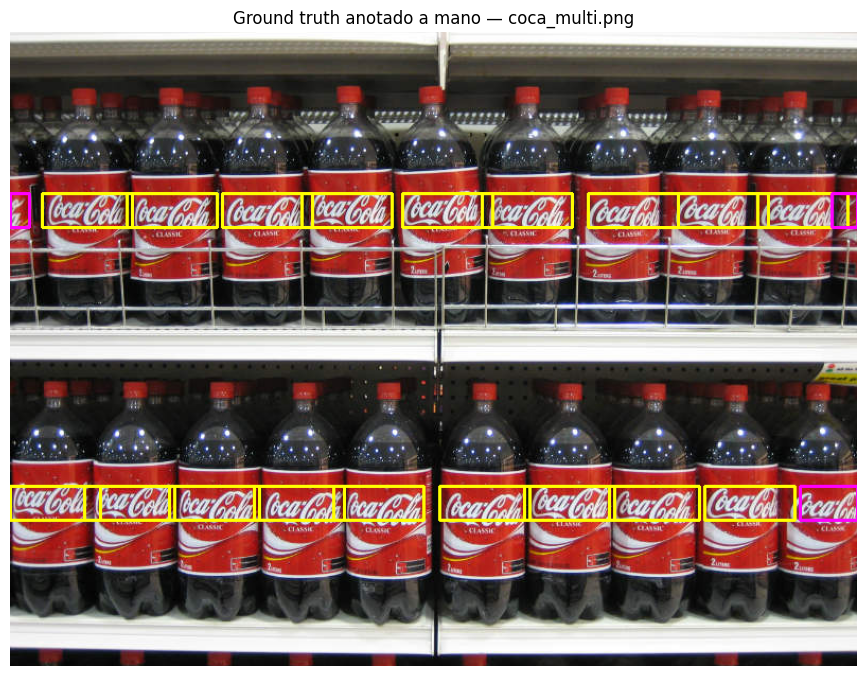

In [11]:
# Ground truth de coca_multi.png: 18 logos evaluables (amarillo) y 3 cortados por el borde (magenta)
gt_vis = cargar(MULTI_IMAGE)
for (x, y, w, h) in GROUND_TRUTH[MULTI_IMAGE]['logos']:
    cv.rectangle(gt_vis, (x, y), (x + w, y + h), (0, 255, 255), 2)
for (x, y, w, h) in GROUND_TRUTH[MULTI_IMAGE]['dificiles']:
    cv.rectangle(gt_vis, (x, y), (x + w, y + h), (255, 0, 255), 2)
mostrar(gt_vis, 'Ground truth anotado a mano — coca_multi.png', ancho=11)

In [12]:
# Validación del Punto 1
eval_p1 = {nombre: evaluar(dets, GROUND_TRUTH[nombre]) for nombre, dets in punto1.items()}

print(f"{'imagen':22s}{'dets':>6}{'TP':>4}{'FP':>4}   IoU con el GT")
for nombre, m in eval_p1.items():
    det = punto1[nombre][0]
    mejor_iou = max(iou(det['caja'], g) for g in GROUND_TRUTH[nombre]['logos'])
    print(f"{nombre:22s}{len(punto1[nombre]):6d}{m['TP']:4d}{m['FP']:4d}   {mejor_iou:.2f}")

r = resumir(eval_p1)
print(f"\nTotal punto 1: {r['TP']}/{len(imagenes)} detecciones correctas, "
      f"{r['FP']} falsos positivos (precisión {r['precision']:.0%})")

imagen                  dets  TP  FP   IoU con el GT
COCA-COLA-LOGO.jpg         1   1   0   0.93
coca_logo_1.png            1   1   0   0.82
coca_logo_2.png            1   1   0   0.79
coca_multi.png             1   1   0   0.87
coca_retro_1.png           1   1   0   0.97
coca_retro_2.png           1   1   0   0.93
logo_1.png                 1   1   0   0.97

Total punto 1: 7/7 detecciones correctas, 0 falsos positivos (precisión 100%)


### Verificación de la doble polaridad

Si el detector hubiera usado una sola versión del template, ¿cuántas imágenes resolvería? Se repite
la selección top-1 restringiendo los candidatos a cada polaridad por separado y se mide el IoU
contra el ground truth.

In [13]:
print(f"{'imagen':22s}{'solo directa':>16}{'solo invertida':>18}   (IoU top-1 contra el GT)")
for nombre in imagenes:
    fila = ''
    for polaridad, ancho_col in (('directa', 16), ('invertida', 18)):
        cands = [c for c in CANDIDATOS[nombre] if c['polaridad'] == polaridad]
        if not cands:
            texto = 'sin candidatos'
        else:
            mejor = max(cands, key=lambda c: c['z'])
            valor = max(iou(mejor['caja'], g) for g in GROUND_TRUTH[nombre]['logos'])
            texto = f"{valor:.2f}" + (' OK' if valor >= IOU_ACIERTO else ' FALLA')
        fila += f'{texto:>{ancho_col}}'
    print(f'{nombre:22s}{fila}')

usadas = [punto1[n][0]['polaridad'] for n in imagenes]
print(f'\nPolaridad elegida por el detector: {usadas.count("invertida")} invertida(s), '
      f'{usadas.count("directa")} directa(s)')

imagen                    solo directa    solo invertida   (IoU top-1 contra el GT)
COCA-COLA-LOGO.jpg          0.04 FALLA           0.93 OK
coca_logo_1.png             0.00 FALLA           0.82 OK
coca_logo_2.png             0.00 FALLA           0.79 OK
coca_multi.png              0.00 FALLA           0.87 OK
coca_retro_1.png               0.97 OK        0.02 FALLA
coca_retro_2.png            0.00 FALLA           0.93 OK
logo_1.png                  0.00 FALLA           0.97 OK

Polaridad elegida por el detector: 6 invertida(s), 1 directa(s)


**Resultado del punto 1:** las 7 detecciones caen sobre el logo verdadero (IoU entre 0.79 y 0.97
contra la anotación manual) y no hay ningún falso positivo. El caso más ajustado es
`coca_logo_2.png`, donde el NCC del match correcto es apenas 0.23 —la lata es oscura, tiene degradé
y el lettering está deformado— y solo la normalización por z-score lo pone en primer lugar.

## Punto 2 — Múltiples detecciones en `coca_multi.png`

Con una sola instancia alcanzaba con tomar el máximo. Con varias hay que decidir **cuántos** de los
candidatos son logos, y eso es lo que define un umbral. Un umbral fijo sobre el NCC no sirve: el
valor absoluto de la correlación depende del contraste y de la nitidez de cada imagen, así que un
número que funciona en la góndola deja afuera todas las detecciones del afiche retro.

La regla que planteamos combina dos condiciones sobre el score $z$ de cada candidato:

$$z \geq \max\big(\underbrace{Z_{min}}_{\text{piso absoluto}},\; \underbrace{Z_{rel} \cdot z_{mejor}}_{\text{relativo a la imagen}}\big)$$

- El **piso absoluto** ($Z_{min} = 4$) exige que el pico se despegue del fondo del mapa de
  correlación al menos 4 desvíos: es la condición de "esto no es ruido".
- El **umbral relativo** ($Z_{rel} = 0.7$) exige que el candidato sea comparable al mejor de esa
  misma imagen. Es lo que adapta el detector a cada foto: si hay muchas instancias iguales sus
  scores son parecidos y sobreviven todas; si hay una sola, los matches secundarios quedan muy por
  debajo del mejor y se descartan.

Ninguna de las dos condiciones alcanza por sí sola, y más abajo se muestra con una ablación por qué.

coca_multi.png: 18 detecciones sobre 18 logos evaluables
  NCC entre 0.43 y 0.56 | z entre 4.01 y 5.37
  {'TP': 18, 'FP': 0, 'FN': 0, 'dificiles': 0}


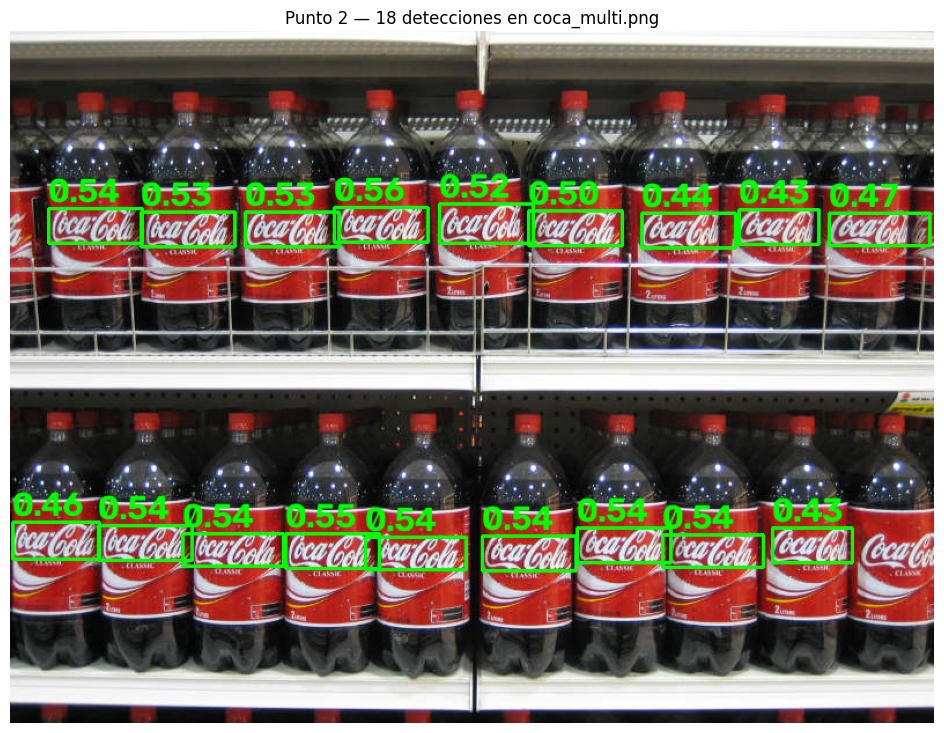

In [14]:
def detectar_logos(nombre: str, z_min: float = Z_MIN, z_rel: float = Z_REL) -> list:
    """Puntos 2 y 3: todas las detecciones de la imagen (piso absoluto + umbral relativo)."""
    candidatos = CANDIDATOS[nombre]
    if not candidatos:
        return []
    umbral = max(z_min, z_rel * candidatos[0]['z'])
    return [c for c in candidatos if c['z'] >= umbral]


multi_dets = detectar_logos(MULTI_IMAGE)
eval_multi = evaluar(multi_dets, GROUND_TRUTH[MULTI_IMAGE])

print(f'{MULTI_IMAGE}: {len(multi_dets)} detecciones sobre '
      f"{len(GROUND_TRUTH[MULTI_IMAGE]['logos'])} logos evaluables")
print(f"  NCC entre {min(d['ncc'] for d in multi_dets):.2f} y {max(d['ncc'] for d in multi_dets):.2f}"
      f" | z entre {min(d['z'] for d in multi_dets):.2f} y {max(d['z'] for d in multi_dets):.2f}")
print(f'  {eval_multi}')

mostrar(dibujar(cargar(MULTI_IMAGE), multi_dets),
        f'Punto 2 — {len(multi_dets)} detecciones en {MULTI_IMAGE}', ancho=12)

### Validación 1: sensibilidad al umbral relativo

El primer chequeo es que el resultado no dependa de haber acertado un valor exacto de $Z_{rel}$.
Se barre el umbral y se cuentan TP, FP y FN contra el ground truth.

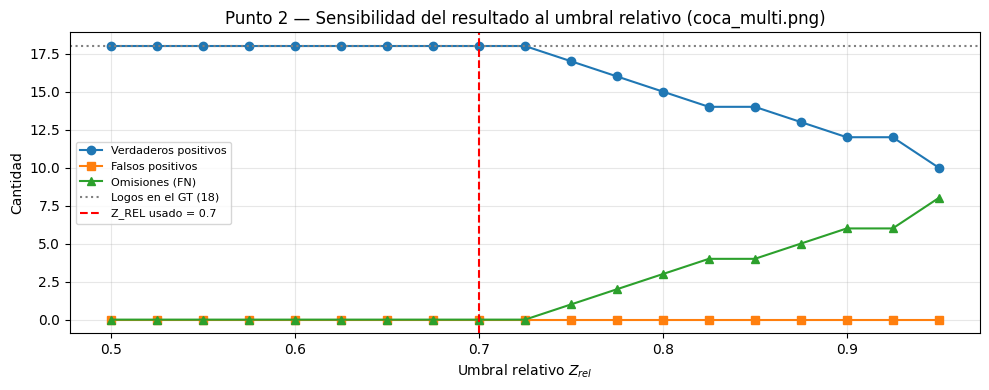

Resultado perfecto (18 TP, 0 FP) para Z_rel en [0.500, 0.725]


In [15]:
barrido = np.arange(0.50, 0.96, 0.025)
curva = [evaluar(detectar_logos(MULTI_IMAGE, z_rel=z), GROUND_TRUTH[MULTI_IMAGE]) for z in barrido]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(barrido, [m['TP'] for m in curva], marker='o', label='Verdaderos positivos')
ax.plot(barrido, [m['FP'] for m in curva], marker='s', label='Falsos positivos')
ax.plot(barrido, [m['FN'] for m in curva], marker='^', label='Omisiones (FN)')
ax.axhline(len(GROUND_TRUTH[MULTI_IMAGE]['logos']), color='gray', ls=':', label='Logos en el GT (18)')
ax.axvline(Z_REL, color='red', ls='--', label=f'Z_REL usado = {Z_REL}')
ax.set_xlabel('Umbral relativo $Z_{rel}$')
ax.set_ylabel('Cantidad')
ax.set_title('Punto 2 — Sensibilidad del resultado al umbral relativo (coca_multi.png)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

meseta = [f'{z:.3f}' for z, m in zip(barrido, curva)
          if m['TP'] == len(GROUND_TRUTH[MULTI_IMAGE]['logos']) and m['FP'] == 0]
print(f'Resultado perfecto (18 TP, 0 FP) para Z_rel en [{meseta[0]}, {meseta[-1]}]')

### Validación 2: ablación de las dos condiciones

El segundo chequeo es que las dos condiciones del umbral hagan falta. Se corre el mismo detector
sobre **todo** el dataset activando una, la otra y las dos.

In [16]:
def detectar_ablacion(nombre: str, usar_piso: bool, usar_relativo: bool) -> list:
    candidatos = CANDIDATOS[nombre]
    umbral = 0.0
    if usar_piso:
        umbral = max(umbral, Z_MIN)
    if usar_relativo:
        umbral = max(umbral, Z_REL * candidatos[0]['z'])
    return [c for c in candidatos if c['z'] >= umbral]


print(f"{'variante':38s}{'TP':>4}{'FP':>5}{'FN':>4}   dónde aparecen los FP")
for etiqueta, piso, rel in (('(a) solo piso absoluto z >= 4', True, False),
                            ('(b) solo umbral relativo 0.7', False, True),
                            ('(c) piso absoluto + umbral relativo', True, True)):
    res = {n: evaluar(detectar_ablacion(n, piso, rel), GROUND_TRUTH[n]) for n in imagenes}
    tot = resumir(res)
    culpables = ', '.join(f'{n} ({m["FP"]})' for n, m in res.items() if m['FP'])
    print(f"{etiqueta:38s}{tot['TP']:4d}{tot['FP']:5d}{tot['FN']:4d}   {culpables or '—'}")

variante                                TP   FP  FN   dónde aparecen los FP
(a) solo piso absoluto z >= 4           24   45   0   COCA-COLA-LOGO.jpg (40), coca_logo_1.png (3), coca_retro_1.png (1), logo_1.png (1)
(b) solo umbral relativo 0.7            24    4   0   coca_logo_2.png (4)
(c) piso absoluto + umbral relativo     24    0   0   —


**Lectura de la ablación.** Con el piso absoluto solo, el detector devuelve 45 falsos positivos:
todos los picos que superan 4σ en imágenes muy texturadas —el fondo de `COCA-COLA-LOGO.jpg`, por
ejemplo— entran como detecciones. Con el umbral relativo solo, quedan 4 falsos positivos, todos en
`coca_logo_2.png`: como ahí el mejor match es débil ($z = 4.7$), el 70% de un valor bajo deja pasar
ruido. Las dos condiciones juntas dan **0 falsos positivos y 0 omisiones** en todo el dataset: una
protege contra las imágenes con mucha textura y la otra contra las imágenes donde el mejor match es
pobre.

**Resultado del punto 2:** 18 detecciones para los 18 logos completos de la góndola, sin falsos
positivos. Las 3 instancias que quedan cortadas por los bordes de la foto no se detectan, algo
esperable: el template busca el logo entero y de esas etiquetas hay menos de medio logo visible.

## Punto 3 — Generalización a todas las imágenes

La función `detectar_logos()` del punto 2 ya es general: no recibe ningún parámetro que dependa de
la imagen, no consulta el nombre del archivo y no sabe cuántos logos tiene que encontrar. La
cantidad de detecciones sale sola de la relación entre los scores de los candidatos de cada imagen.
Se la aplica tal cual a las 7 imágenes.

In [17]:
punto3 = {nombre: detectar_logos(nombre) for nombre in imagenes}
eval_p3 = {nombre: evaluar(dets, GROUND_TRUTH[nombre]) for nombre, dets in punto3.items()}

print(f"{'imagen':22s}{'dets':>5}{'GT':>4}{'TP':>4}{'FP':>4}{'FN':>4}   confianzas (NCC)")
for nombre, m in eval_p3.items():
    ncc = ' '.join(f"{d['ncc']:.2f}" for d in punto3[nombre][:6])
    extra = ' ...' if len(punto3[nombre]) > 6 else ''
    print(f"{nombre:22s}{len(punto3[nombre]):5d}{len(GROUND_TRUTH[nombre]['logos']):4d}"
          f"{m['TP']:4d}{m['FP']:4d}{m['FN']:4d}   {ncc}{extra}")

total = resumir(eval_p3)
print(f"\nTOTAL: TP={total['TP']} FP={total['FP']} FN={total['FN']} | "
      f"precisión={total['precision']:.3f} recall={total['recall']:.3f} F1={total['f1']:.3f}")

imagen                 dets  GT  TP  FP  FN   confianzas (NCC)
COCA-COLA-LOGO.jpg        1   1   1   0   0   0.71
coca_logo_1.png           1   1   1   0   0   0.41
coca_logo_2.png           1   1   1   0   0   0.23
coca_multi.png           18  18  18   0   0   0.56 0.55 0.54 0.54 0.54 0.54 ...
coca_retro_1.png          1   1   1   0   0   0.69
coca_retro_2.png          1   1   1   0   0   0.65
logo_1.png                1   1   1   0   0   0.42

TOTAL: TP=24 FP=0 FN=0 | precisión=1.000 recall=1.000 F1=1.000


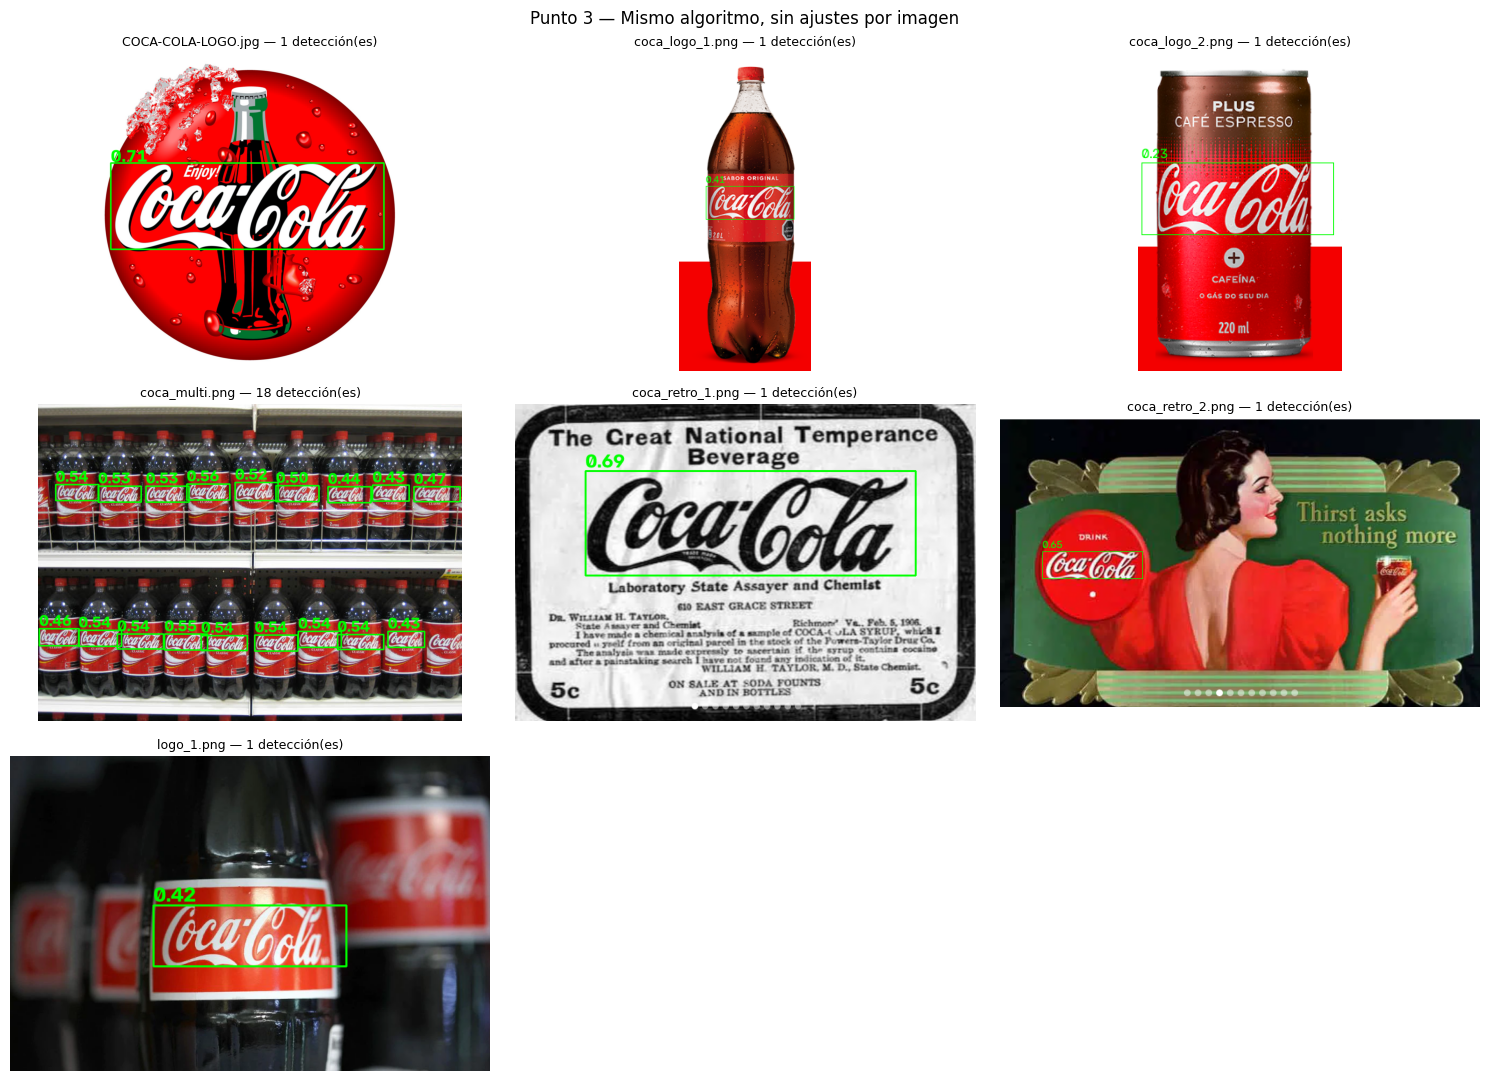

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()
for ax, nombre in zip(axes, imagenes):
    ax.imshow(cv.cvtColor(dibujar(cargar(nombre), punto3[nombre]), cv.COLOR_BGR2RGB))
    ax.set_title(f'{nombre} — {len(punto3[nombre])} detección(es)', fontsize=9)
    ax.axis('off')
for ax in axes[len(imagenes):]:
    ax.axis('off')
plt.suptitle('Punto 3 — Mismo algoritmo, sin ajustes por imagen')
plt.tight_layout()
plt.show()

**Resultado del punto 3:** el mismo algoritmo devuelve 1 detección en cada una de las 6 imágenes de
logo único y 18 en la góndola, con **precisión y recall de 1.00** sobre los 24 logos evaluables del
ground truth. Las 5 instancias marcadas como difíciles siguen sin detectarse, que es el límite
razonable del método (más abajo se analiza por qué).

## Extra — Contraste con un detector por características locales (SIFT)

El template matching resolvió el TP, pero conviene ver qué pasa con el enfoque de la Clase 5, que es
el que uno usaría si el logo apareciera rotado o con perspectiva fuerte: extraer **keypoints SIFT**
del template y de la imagen, aparearlos con **FLANN** filtrando por el **ratio de Lowe**, y estimar
una **homografía con RANSAC** para proyectar el contorno del template sobre la imagen.

Un detalle importante: SIFT **tampoco** es invariante a la inversión de contraste (el descriptor se
arma con histogramas de gradientes orientados, y al invertir la imagen los gradientes rotan 180°).
Así que aplica la misma solución del punto anterior: se prueban las dos polaridades del template y
se conserva la que deja más inliers.

Sirve además como **validación cruzada** del punto 1: son dos algoritmos independientes, y si los
dos ubican el logo en el mismo lugar es una señal fuerte de que la detección es correcta y no un
artefacto del método.

In [19]:
sift = cv.SIFT_create()
flann = cv.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))


def detectar_sift(img_bgr: np.ndarray, tpl_bgr: np.ndarray = template_bgr) -> dict | None:
    """SIFT + FLANN + ratio de Lowe + homografía con RANSAC, probando ambas polaridades."""
    kp_img, desc_img = sift.detectAndCompute(cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY), None)
    if desc_img is None:
        return None
    base = cv.cvtColor(recortar_template(tpl_bgr), cv.COLOR_BGR2GRAY)
    mejor = None
    for polaridad, tmpl in (('directa', base), ('invertida', 255 - base)):
        kp_tpl, desc_tpl = sift.detectAndCompute(tmpl, None)
        if desc_tpl is None:
            continue
        pares = flann.knnMatch(desc_tpl, desc_img, k=2)
        buenos = [m for m, n in pares if m.distance < LOWE_RATIO * n.distance]
        if len(buenos) < 4:
            continue
        origen = np.float32([kp_tpl[m.queryIdx].pt for m in buenos]).reshape(-1, 1, 2)
        destino = np.float32([kp_img[m.trainIdx].pt for m in buenos]).reshape(-1, 1, 2)
        H, mascara = cv.findHomography(origen, destino, cv.RANSAC, 5.0)
        if H is None:
            continue
        alto, ancho = tmpl.shape
        esquinas = cv.perspectiveTransform(
            np.float32([[0, 0], [0, alto], [ancho, alto], [ancho, 0]]).reshape(-1, 1, 2), H)
        pts = esquinas.reshape(-1, 2)
        x0, y0 = pts.min(axis=0)
        x1, y1 = pts.max(axis=0)
        cand = {'polaridad': polaridad, 'buenos': len(buenos), 'inliers': int(mascara.sum()),
                'caja': (int(x0), int(y0), int(x1 - x0), int(y1 - y0)), 'esquinas': esquinas,
                'kp_tpl': kp_tpl, 'kp_img': kp_img, 'matches': buenos, 'mascara': mascara,
                'template': tmpl}
        if mejor is None or cand['inliers'] > mejor['inliers']:
            mejor = cand
    return mejor

In [20]:
print(f"{'imagen':22s}{'polaridad':12s}{'matches':>8}{'inliers':>8}{'IoU vs GT':>11}{'IoU vs TM':>11}")
resultados_sift = {}
for nombre in imagenes:
    res = detectar_sift(cargar(nombre))
    resultados_sift[nombre] = res
    if res is None:
        print(f'{nombre:22s}{"—":12s}{"sin homografía (menos de 4 matches)":>38s}')
        continue
    gt_iou = max(iou(res['caja'], g) for g in GROUND_TRUTH[nombre]['logos'])
    tm_iou = iou(res['caja'], punto1[nombre][0]['caja'])
    print(f"{nombre:22s}{res['polaridad']:12s}{res['buenos']:8d}{res['inliers']:8d}"
          f"{gt_iou:11.2f}{tm_iou:11.2f}")

imagen                polaridad    matches inliers  IoU vs GT  IoU vs TM
COCA-COLA-LOGO.jpg    invertida         22      10       0.90       0.95


coca_logo_1.png       invertida         35      27       0.95       0.83
coca_logo_2.png       invertida         27      19       0.68       0.86
coca_multi.png        —              sin homografía (menos de 4 matches)


coca_retro_1.png      directa           23      16       0.89       0.91
coca_retro_2.png      invertida         27      21       0.95       0.93
logo_1.png            invertida         29      20       0.82       0.85


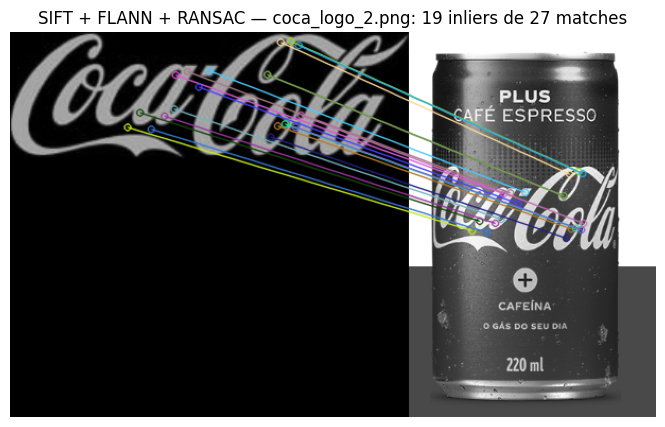

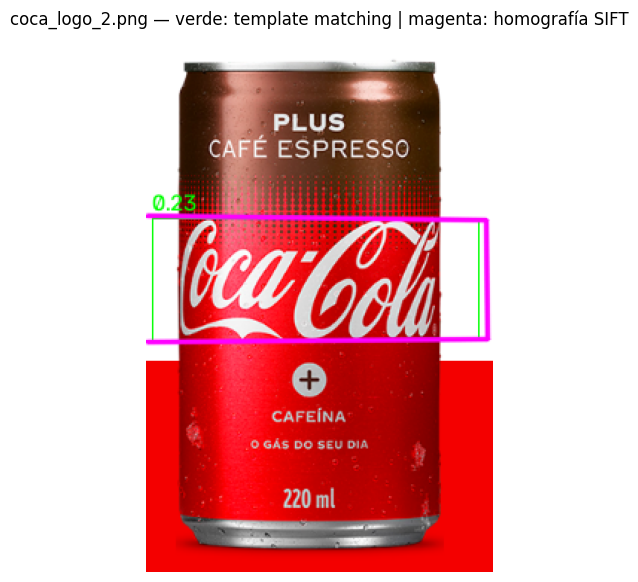

In [21]:
# Correspondencias y contorno proyectado en el caso más difícil para template matching
nombre = 'coca_logo_2.png'
img = cargar(nombre)
res = resultados_sift[nombre]

lienzo = cv.drawMatches(res['template'], res['kp_tpl'], cv.cvtColor(img, cv.COLOR_BGR2GRAY),
                        res['kp_img'], res['matches'], None,
                        matchesMask=res['mascara'].ravel().tolist(),
                        flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(13, 5))
plt.imshow(lienzo, cmap='gray')
plt.title(f"SIFT + FLANN + RANSAC — {nombre}: {res['inliers']} inliers de {res['buenos']} matches")
plt.axis('off')
plt.show()

comparacion = dibujar(img, punto1[nombre], (0, 255, 0))
cv.polylines(comparacion, [np.int32(res['esquinas'])], True, (255, 0, 255), 2, cv.LINE_AA)
mostrar(comparacion, f'{nombre} — verde: template matching | magenta: homografía SIFT', ancho=4.5)

### Dónde falla cada enfoque

SIFT ubica el logo en las 6 imágenes de instancia única con muy buena precisión (IoU 0.68 a 0.95
contra el ground truth) y coincide con el template matching —el IoU entre las cajas de los dos
métodos va de 0.83 a 0.95—, pero **no llega a una homografía en `coca_multi.png`**: el ratio de Lowe
descarta casi todos los pares. Y tiene sentido, porque es justamente el escenario que rompe el
criterio de Lowe: cuando hay 18 copias idénticas del mismo objeto, cada descriptor del template
tiene 18 vecinos casi equidistantes en la imagen, la relación entre el primero y el segundo se
acerca a 1 y el filtro los tira a todos. A eso se suma que cada etiqueta mide 87x28 px, con lo cual
el logo aporta muy pocos keypoints estables: ni siquiera agrandando la imagen alcanza para estimar
una homografía confiable.

In [22]:
# Verificación: SIFT sobre coca_multi, incluso agrandando la imagen
img_multi = cargar(MULTI_IMAGE)
for factor in (1, 2, 3):
    escalada = cv.resize(img_multi, None, fx=factor, fy=factor, interpolation=cv.INTER_CUBIC)
    res = detectar_sift(escalada)
    detalle = 'sin homografía' if res is None else f"{res['buenos']} matches, {res['inliers']} inliers"
    print(f'coca_multi.png a {factor}x -> {detalle}   (18 logos presentes)')

coca_multi.png a 1x -> sin homografía   (18 logos presentes)


coca_multi.png a 2x -> sin homografía   (18 logos presentes)


coca_multi.png a 3x -> 9 matches, 4 inliers   (18 logos presentes)


La conclusión práctica es que los dos métodos son complementarios: SIFT es el indicado cuando el
objeto es único y puede aparecer rotado, escalado o en perspectiva; el template matching
multi-escala es el que funciona cuando el objeto es chico, se repite muchas veces y aparece siempre
con la misma orientación, que es exactamente el caso de la góndola.

## Conclusiones

**Un solo detector para los tres puntos.** El pipeline es el mismo en toda la entrega —barrido
multi-escala con `TM_CCOEFF_NORMED`, NMS y umbral— y lo único que cambia entre el punto 1 y los
puntos 2 y 3 es la regla de selección: top-1 contra "todos los que superan el umbral". Eso hace que
la generalización del punto 3 no requiera nada nuevo: la función del punto 2 se aplica tal cual a
las 7 imágenes y devuelve 1 detección donde hay un logo y 18 donde hay 18, sin mirar el nombre del
archivo ni recibir la cantidad esperada.

**La polaridad importa tanto como la escala.** Fue el hallazgo que más cambió los resultados.
`TM_CCOEFF_NORMED` correlaciona variaciones de intensidad, así que el logo blanco sobre rojo de las
etiquetas es, para la métrica, el negativo del template rojo sobre blanco. Los números están en la
tabla de verificación del punto 1: con el template directo únicamente, 6 de las 7 imágenes fallan;
con el invertido únicamente, falla el aviso de diario, que es el único caso donde el logo aparece
oscuro sobre claro como en el template. Buscando con las dos y quedándose con la mejor, resuelven
las 7. Lo mismo vale para SIFT, por la misma razón: al invertir el contraste los gradientes rotan
180° y los descriptores dejan de aparearse.

**El NCC crudo no es comparable entre escalas.** Cuanto más chico es el template, más fácil es que
un parche cualquiera lo correlacione bien, así que el máximo global de una pirámide de escalas
tiende a caer en las escalas chicas sobre falsos positivos. Normalizando cada pico contra la media y
el desvío de su propio mapa de correlación ($z$-score, la idea del *peak-to-sidelobe ratio*) los
picos se vuelven comparables entre escalas. En `coca_logo_2.png` esa sola diferencia decide entre
detectar el logo (z = 4.7, NCC = 0.23) o devolver el bloque de texto de la lata (NCC = 0.34, z =
3.6): el match "peor" según NCC es el correcto. Y sin el ancho mínimo de búsqueda el efecto se
agrava, el máximo de NCC se corre a un parche de 55x15 px, mientras que el de $z$ se mantiene sobre
el logo.

**El umbral tiene que ser mitad absoluto y mitad relativo.** La ablación sobre el dataset completo lo
muestra con números: solo con el piso absoluto de 4σ aparecen 45 falsos positivos en las imágenes
texturadas; solo con el umbral relativo al mejor score de la imagen quedan 4, todos en la imagen
donde el mejor match es débil. Combinando ambos, 0 falsos positivos y 0 omisiones sobre 24 logos.
Además el resultado es estable: en `coca_multi.png` cualquier $Z_{rel}$ entre 0.50 y 0.72 da las 18
detecciones exactas, así que no estamos parados sobre un valor afortunado.

**NMS por IoU + distancia entre centros.** El IoU solo no alcanzaba: las cajas chicas que caen sobre
una parte del logo (la palabra *CLASSIC*, por ejemplo) solapan poco con la caja buena y sobrevivían
como detecciones repetidas. Agregar la condición de distancia mínima entre centros —dos botellas no
pueden tener sus logos a menos de media anchura de distancia— las elimina sin tocar las buenas.

**Resultados.** 24 logos detectados sobre 24 evaluables, 0 falsos positivos (precisión 1.00,
recall 1.00, F1 1.00). Quedan sin detectar las 5 instancias marcadas como difíciles, y las tres
razones son entendibles y esperables: instancias **cortadas por el borde** de la imagen (3 en la
góndola), una instancia **demasiado chica** (44x14 px en el vaso del afiche retro, por debajo del
ancho mínimo de búsqueda) y una **fuera de foco** (la botella del fondo en `logo_1.png`, cuyo mejor
score es z = 3.1, indistinguible del ruido de esa imagen). Bajar el umbral para recuperarla implica
aceptar una docena y media de falsos positivos antes.

**Limitaciones y qué haríamos distinto.** El template matching no modela rotación ni perspectiva:
alcanza con inclinar el logo unos grados para que la correlación se caiga. Lo compensamos
parcialmente barriendo relaciones de aspecto, que cubre la deformación de las superficies
cilíndricas, pero no es una solución general. Para eso está el enfoque por características locales,
que resolvió las 6 imágenes de instancia única con mejor localización que el template matching
(IoU 0.95 contra 0.82 en `coca_logo_1.png`) y sin necesidad de barrer escalas. La contracara es que
SIFT se cae justo en el caso del punto 2: con 18 copias idénticas del mismo objeto, el ratio de
Lowe descarta prácticamente todos los pares, porque cada descriptor del template tiene muchos
vecinos igual de cercanos. Los dos métodos cubren huecos distintos, y un detector de producción
probablemente correría los dos.